In [20]:
## DIPY Segmentation (WM, GM, CSF, Background)
import numpy as np
import matplotlib.pyplot as plt
from dipy.segment.tissue import TissueClassifierHMRF
from dipy.io.image import load_nifti
import time
from matplotlib.colors import LinearSegmentedColormap
import nibabel as nib
from nibabel import Nifti1Image 


In [10]:
# Get NIFTI image
data, affine, img = load_nifti("E:\\Documents\\masked_nifti.nii", return_img = True)


# image = img.slicer[40:-40, 15:-25]
orig = img.get_fdata()
print(type(orig))

<class 'numpy.memmap'>


In [11]:
# Choose number of classes and beta value
nclass = 3
beta = 0.1

In [12]:
# Compute segmentation
t0 = time.time()
hmrf = TissueClassifierHMRF()
initial_segmentation, final_segmentation, PVE = hmrf.classify(orig, nclass, beta)
t1 = time.time()
total_time = t1-t0
print('Total time:' + str(total_time))


>> Iteration: 0
>> Iteration: 1
>> Iteration: 2
>> Iteration: 3
>> Iteration: 4
>> Iteration: 5
>> Iteration: 6
>> Iteration: 7
>> Iteration: 8
>> Iteration: 9
>> Iteration: 10
>> Iteration: 11
>> Iteration: 12
>> Iteration: 13
>> Iteration: 14
Total time:105.37882041931152


In [14]:
# Define the values and colors for segmentation cmap
colors = ['black', 'purple', 'orange', 'firebrick']
values = [0, 1, 2, 3]
labels = ['CSF', 'GM', 'WM']


# Create a custom colormap dictionary
seg_cmap = LinearSegmentedColormap.from_list("mycmap", list(zip(values, colors)))


In [15]:
print(orig.shape)
print(final_segmentation.shape)

(256, 256, 160)
(256, 256, 160)


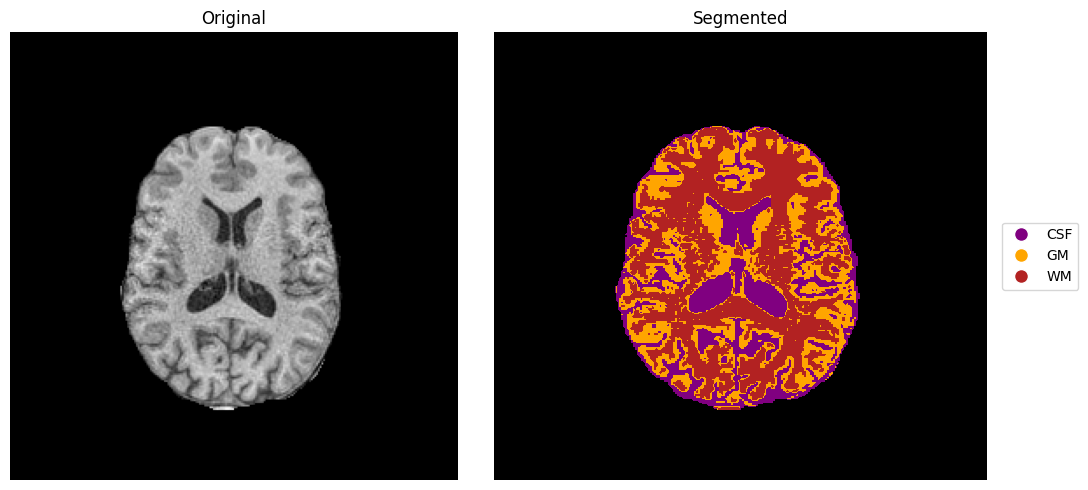

In [13]:
# Plot segmentation before and after
axial_middle = data.shape[2] // 2

# Create a figure with three subplots
fig, axes = plt.subplots(1, 2)
fig.set_size_inches(11, 5) 

# First subplot - data[:, :, axial_middle]
axes[0].set_axis_off()
axes[0].imshow(data[:, :, 89].T, cmap='gray', origin='lower')
axes[0].set_title('Original')

# Second subplot - final_segmentation[..., 89] with legend
axes[1].set_axis_off()
image = axes[1].imshow(np.rot90(final_segmentation[..., 89]), cmap=plt.cm.colors.ListedColormap(colors), aspect='auto')
axes[1].set_title('Segmented')
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label)
                   for label, color in zip(labels, colors[1:])]
axes[1].legend(handles=legend_elements, loc='center right', bbox_to_anchor=(1.2, 0.5))

# Adjust the spacing between subplots
plt.tight_layout()

# Save the figure
plt.savefig('final_seg.png', bbox_inches='tight', pad_inches=0)

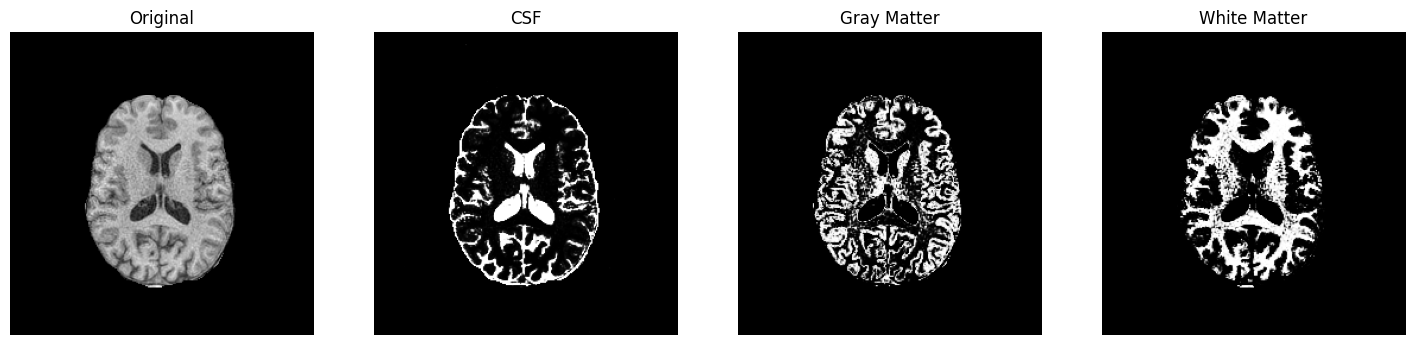

In [16]:
# Plot probability masks for CSF, WM, GM
fig = plt.figure(figsize=(18, 9))

# Original image plot
a = fig.add_subplot(1, 4, 1)
img_additional_slice = np.rot90(data[:, :, 89])
imgplot = plt.imshow(img_additional_slice, cmap="gray")
a.axis('off')
a.set_title('Original')

# CSF probability mask
a = fig.add_subplot(1, 4, 2)
img_ax = np.rot90(PVE[..., 89, 0])
imgplot = plt.imshow(img_ax, cmap="gray")
a.axis('off')
a.set_title('CSF')

# Gray Matter probability mask
a = fig.add_subplot(1, 4, 3)
img_cor = np.rot90(PVE[:, :, 89, 1])
imgplot = plt.imshow(img_cor, cmap="gray")
a.axis('off')
a.set_title('Gray Matter')

# White Matter probability mask
a = fig.add_subplot(1, 4, 4)
img_cor = np.rot90(PVE[:, :, 89, 2])
imgplot = plt.imshow(img_cor, cmap="gray")
a.axis('off')
a.set_title('White Matter')

plt.savefig('probabilities.png', bbox_inches='tight', pad_inches=0)
plt.show()

In [21]:
## Save segmented nifti file
segmentation = Nifti1Image(final_segmentation, affine)
nib.save(segmentation,"E:\\Documents\\segmented.nii")